In [8]:
from rnn import LeakyRNN
from trainers import *
from analysis import *
import motornet as mn
from plot import plot_per_direction_comparison, plot_reach_trajectories, plot_training_curves
import torch
import copy
import matplotlib.pyplot as plt
import numpy as np

In [2]:
torch.manual_seed(0)
effector = mn.effector.ReluPointMass24(timestep=0.01) # 2D point mass, 4 muscles
env = mn.environment.RandomTargetReach(effector=effector, max_ep_duration=1.0)
n_in = env.observation_space.shape[0]
n_out = env.n_muscles

lr = 5e-2

## Smoke Tests

In [3]:
effector = mn.effector.ReluPointMass24(timestep=0.01) # 2D point mass, 4 muscles
env = mn.environment.CenterOutReach(reaching_distance=0.2, effector=effector, max_ep_duration=1.0)

n_in = env.observation_space.shape[0]
n_out = env.n_muscles

lr = 5e-2

In [12]:
bptt_net = LeakyRNN(n_in=n_in, n_rec=64, n_out=n_out, tau=10.0)
rflo_net = copy.deepcopy(bptt_net)
rflo_trainer = RFLOTrainer(rflo_net, env, loss_fn=position_loss, lr=5e-2)
bptt_trainer = BPTTTrainer(bptt_net, env, loss_fn=position_loss, lr=5e-2)

In [13]:
bptt_losses, bptt_metrics = bptt_trainer.train(num_steps=8000)

In [14]:
rflo_losses, rflo_metrics = rflo_trainer.train(num_steps=8000)

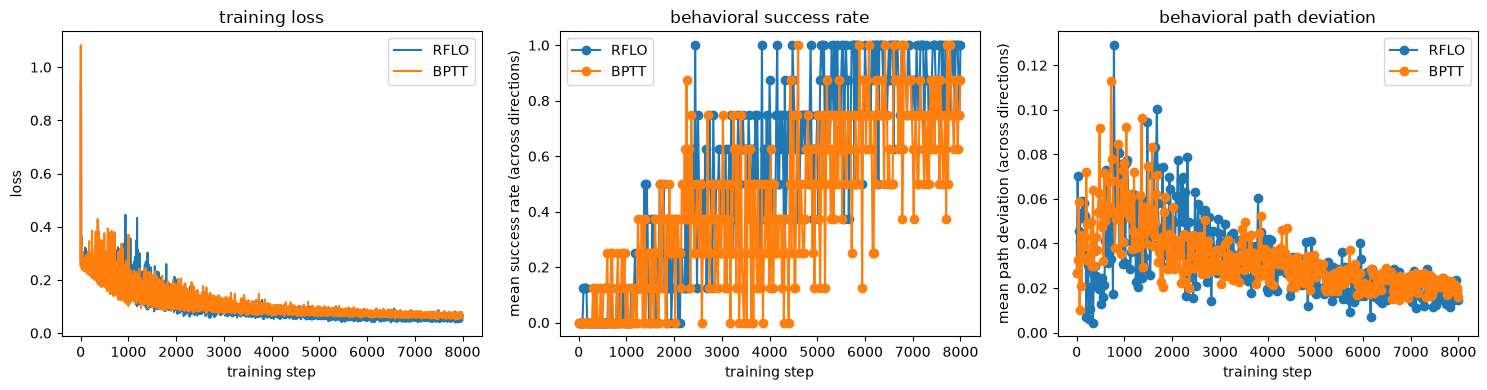

In [15]:
fig = plot_training_curves({
    "RFLO": (rflo_losses, rflo_metrics),
    "BPTT": (bptt_losses, bptt_metrics),
})

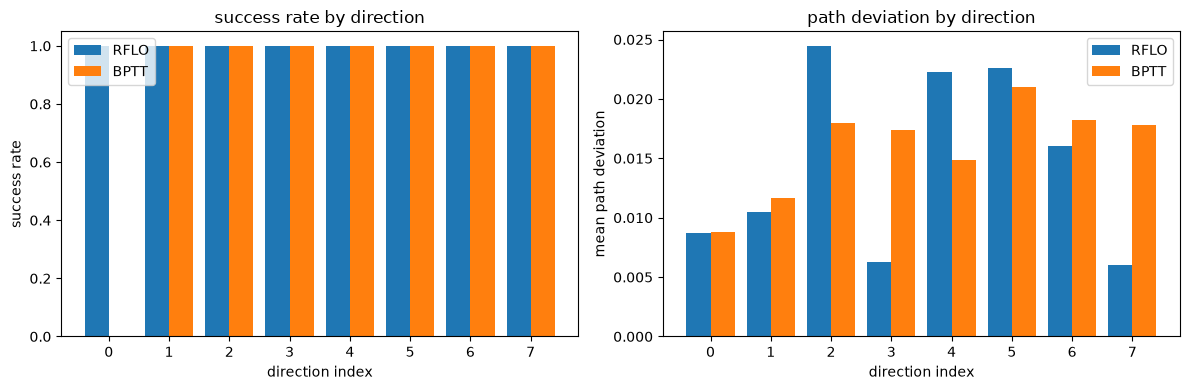

In [16]:
final_step_bptt, final_bptt = bptt_metrics[-1]
final_step_rflo, final_rflo = rflo_metrics[-1]
fig = plot_per_direction_comparison({"RFLO": final_rflo, "BPTT": final_bptt})

RFLO


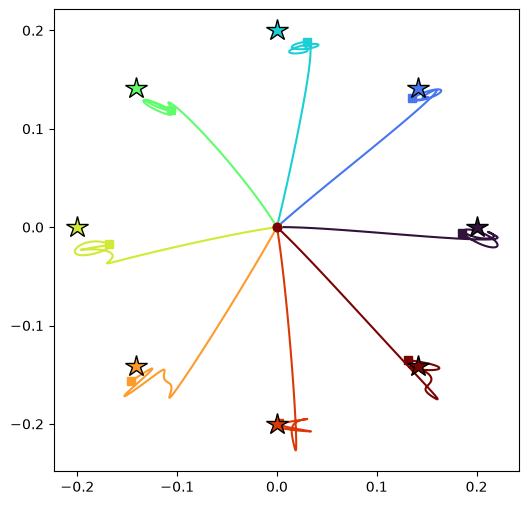

BPTT


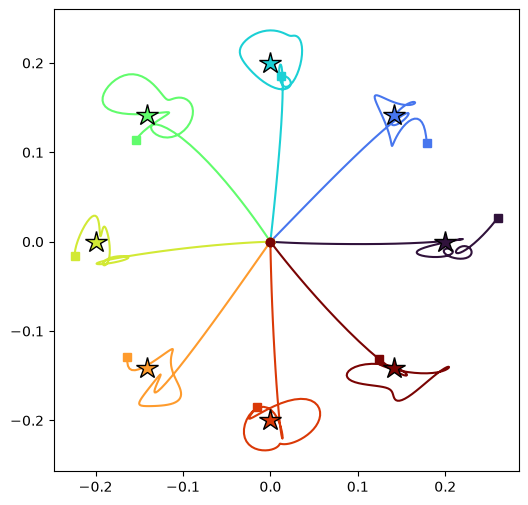

In [17]:
for trainer, name in [(rflo_trainer, "RFLO"), (bptt_trainer, "BPTT")]:
    options = {"direction_idx": np.arange(trainer.env.n_targets)}
    H, Y, FT, goal, direction_idx = trainer.inference(options=options)
    FT = FT.permute(1, 0, 2)
    print(name)
    plot_reach_trajectories(FT, goal, direction_idx)

In [5]:
W_before = {k: v.detach().clone() for k, v in
            (("W_rec", rflo_net.W_rec), ("W_in", rflo_net.W_in), ("W_out", rflo_net.W_out))}

In [6]:
loss0 = rflo_trainer.train_step(batch_size=8)
print("loss after 1 step:", loss0)
assert torch.isfinite(torch.tensor(loss0)), "loss is not finite"

loss after 1 step: 0.2702752947807312


In [7]:
assert rflo_net.W_rec.grad is None, "W_rec.grad should be None because RFLO shouldn't call backward() on the params"
assert rflo_net.W_in.grad is None and rflo_net.W_out.grad is None

In [8]:
# testing that the weights did change though
assert not torch.equal(rflo_net.W_rec, W_before["W_rec"]), "W_rec did not change — no update applied"
assert not torch.equal(rflo_net.W_in,  W_before["W_in"]),  "W_in did not change"
assert not torch.equal(rflo_net.W_out, W_before["W_out"]), "W_out did not change"
print("W_rec moved by:", (rflo_net.W_rec - W_before["W_rec"]).norm().item())

W_rec moved by: 0.11816728115081787


In [9]:
assert rflo_trainer.B.shape == (rflo_net.n_rec, rflo_net.n_out), f"unexpected B shape {tuple(trainer.B.shape)}"

In [10]:
net_a = LeakyRNN(n_in=n_in, n_rec=64, n_out=n_out, tau=10.0)
net_b = LeakyRNN(n_in=n_in, n_rec=64, n_out=n_out, tau=10.0)
B = RFLOTrainer(net_a, env, loss_fn=position_loss, lr=5e-2).B
B_seed0_again = RFLOTrainer(net_a, env, loss_fn=position_loss, lr=5e-2).B
B_seed99      = RFLOTrainer(net_b, env, loss_fn=position_loss, lr=5e-2, seed=99).B
assert torch.equal(B, B_seed0_again), "default seed should reproduce the same B"
assert not torch.equal(B, B_seed99),  "seed=99 should give a different B"

In [11]:
rflo_losses = [rflo_trainer.train_step(batch_size=32) for _ in range(100)]
assert all(torch.isfinite(torch.tensor(l)) for l in rflo_losses), "loss diverged to nan/inf"

In [12]:
print("first 5:", [round(l, 4) for l in rflo_losses[:5]])
print("last  5:", [round(l, 4) for l in rflo_losses[-5:]])
print("mean first 10:", round(sum(rflo_losses[:10]) / 10, 4),
      "| mean last 20:", round(sum(rflo_losses[-20:]) / 20, 4))
assert sum(rflo_losses[-20:]) / 20 < sum(rflo_losses[:10]) / 10, "loss did not decrease"

first 5: [0.2779, 0.4512, 0.303, 0.3693, 0.422]
last  5: [0.2708, 0.2805, 0.2551, 0.2492, 0.2389]
mean first 10: 0.4593 | mean last 20: 0.263


In [13]:
print("weight snapshots collected:", len(rflo_trainer.weight_history),
      "| each of length:", rflo_trainer.weight_history[0].numel())
assert rflo_trainer.weight_history[0].numel() == rflo_net.n_rec * rflo_net.n_rec  # W_rec, flattened

weight snapshots collected: 101 | each of length: 4096


In [14]:
H, Y, FT, goals, direction_idx = rflo_trainer.inference(batch_size=8)
print("hidden states H:", tuple(H.shape))  # (T, batch, n_rec)
print("actions Y:", tuple(Y.shape))        # (T, batch, n_out)
assert H.shape[1:] == (8, rflo_net.n_rec) 
assert Y.shape[1:] == (8, rflo_net.n_out)
print("FT shape:", tuple(FT.shape)) # (T, batch, 2)
print("goals:", goals)

TypeError: BaseTrainer.inference() got an unexpected keyword argument 'batch_size'

## Run Trainers

In [42]:
def run(TrainerClass, lr=5e-2, steps=200, bs=32):
    torch.manual_seed(0)
    n = LeakyRNN(n_in=n_in, n_rec=64, n_out=n_out, tau=10.0)
    t = TrainerClass(n, env, loss_fn=position_loss, lr=lr, device="cpu")
    return t, [t.train_step(batch_size=bs) for _ in range(steps)]

rflo_trainer, Lr = run(RFLOTrainer, steps=2000)
bptt_trainer, Lb = run(BPTTTrainer, steps=2000)
print("RFLO last-20 mean:", round(sum(Lr[-20:]) / 20, 4))
print("BPTT last-20 mean:", round(sum(Lb[-20:]) / 20, 4))

RFLO last-20 mean: 0.1271
BPTT last-20 mean: 0.1195


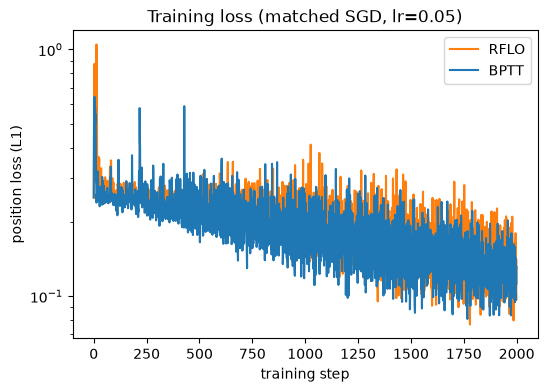

In [43]:
plt.figure(figsize=(6,4))
plt.plot(Lr, label="RFLO", color="C1")
plt.plot(Lb, label="BPTT", color="C0")
plt.yscale("log"); plt.xlabel("training step"); plt.ylabel("position loss (L1)")
plt.title(f"Training loss (matched SGD, lr={5e-2})"); plt.legend(); plt.show()

In [44]:
rflo_h, rflo_y, rflo_ft, rflo_goals, rflo_direction_idx = rflo_trainer.inference(128)
bptt_h, bptt_y, bptt_ft, bptt_goals, bptt_direction_idx, = bptt_trainer.inference(128)

In [45]:
rflo_ft = rflo_ft.permute(1, 0, 2).cpu().numpy()
bptt_ft = bptt_ft.permute(1, 0, 2).cpu().numpy()
print(reach_metrics(rflo_ft, rflo_goals, center=None, success_radius=0.05))

(0.1484375, 0.03742561489343643)


In [46]:
print(reach_metrics(bptt_ft, bptt_goals, center=None, success_radius=0.05))

(0.3984375, 0.053782228380441666)


In [47]:
print(per_direction_metrics(bptt_ft, bptt_goals, bptt_direction_idx))

{0: (1.0, 0.0723806843161583), 1: (0.0, 0.0715126171708107), 2: (0.0, 0.05378706008195877), 3: (1.0, 0.023881658911705017), 4: (0.0, 0.03894298896193504), 5: (0.0, 0.0869157686829567), 6: (0.0, 0.07430534064769745), 7: (1.0, 0.009197355248034)}


In [48]:
labels = ["RFLO", "BPTT"]
similarities = run_dsa([rflo_h, bptt_h],
                       n_delays=5, rank=20, delay_interval=1,
                       iters=500, lr=1e-2, score_method="angular")
print("DSA distance RFLO vs BPTT:", similarities[0, 1])


DSA distance RFLO vs BPTT: 0.09556369483470917


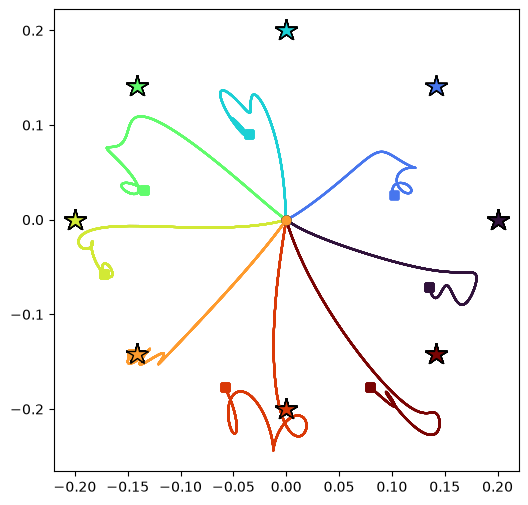

In [49]:
from plot import plot_reach_trajectories
plot_reach_trajectories(rflo_ft, rflo_goals, rflo_direction_idx)

In [23]:
B = 4  # trials to show
with torch.no_grad():
    h = net.init_hidden(B)
    obs, info = env.reset(seed=0, options={"batch_size": B})  # seed => reproducible targets
    goal = info["goal"].cpu().numpy()                          # (B, 2) random targets
    FT = []
    done = False
    while not done:
        u, h, z, y = net.step(obs, h)
        obs, r, done, trunc, info = env.step(action=y)
        FT.append(info["states"]["fingertip"])
    FT = torch.stack(FT).permute(1, 0, 2).cpu().numpy()        # (B, T, 2)

plt.figure(figsize=(6, 6))
colors = plt.cm.tab10(np.arange(B) % 10)
for i in range(B):
    plt.plot(FT[i, :, 0], FT[i, :, 1], color=colors[i], lw=1.5)  # path
    plt.plot(FT[i, 0, 0],  FT[i, 0, 1],  'o', color=colors[i], ms=6)   # start
    plt.plot(FT[i, -1, 0], FT[i, -1, 1], 's', color=colors[i], ms=6)   # end
    plt.plot(goal[i, 0], goal[i, 1], '*', color=colors[i], ms=16, mec='k')  # target
    d = np.linalg.norm(FT[i, -1] - goal[i])
    print(f"trial {i}: final dist to target = {d:.3f} m")

plt.gca().set_aspect('equal')
plt.xlabel('X (m)'); plt.ylabel('Y (m)')
plt.title('Random reach — ○ start, □ end, ★ target')
plt.show()

NameError: name 'net' is not defined

In [ ]:
BPTT_net = 